# 08 - Quadratic Forms and Stabilization Patterns

In this notebook, we move from the **Intersection Form** (bilinear) to the **Quadratic Form** (refinement). While the intersection form captures global gluing, the quadratic form captures the "twisting" of normal bundles, which is essential for defining surgery obstructions in certain dimensions (specifically $4k+2$).

We also introduce the concept of **Stabilization**, which is the process of simplifying a topological classification problem by taking connected sums with $S^2 \times S^2$.

## Learning Goals
- **Quadratic Refinement**: Understand how to define a quadratic mapping $q: H \to \mathbb{Z}_2$ that refines the intersection form.
- **The Arf Invariant**: Learn to compute the binary obstruction that distinguishes "knotted" from "unknotted" structures.
- **Stabilization Logic**: Use `pySurgery` to model the addition of hyperbolic $H$-forms.
- **Definite vs Indefinite**: Explore how stabilization transforms definite forms into indefinite ones.
- **Visualizing Stabilization**: Look at how the spectral signature changes as we stabilize.

## Formal Grounding

### Quadratic Enhancement
A quadratic form $q$ on a vector space $V$ over $\mathbb{Z}_2$ is a map $q: V \to \mathbb{Z}_2$ such that:
$$q(x + y) = q(x) + q(y) + B(x, y)$$
where $B(x, y)$ is the associated bilinear form (the intersection form mod 2). 

### Stabilization
Topologically, stabilization corresponds to $M \# (S^n \times S^n)$. Algebraically, it means:
$$Q \mapsto Q \oplus H, \quad H = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$
Wall's theorem implies that after enough stabilizations, many classification problems become much easier.

| Concept | Algebraic Operation | Topological Meaning |
|---|---|---|
| **Quadratic Form** | $q(x)$ | Normal bundle twist (Arf) |
| **Stabilization** | $\oplus H$ | $M \# (S^2 \times S^2)$ |
| **Hyperbolic Pair**| $\{e, f\}$ s.t. $Q(e,f)=1, Q(e,e)=0$ | A pair of dual 2-spheres |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pysurgery.core.intersection_forms import IntersectionForm
from pysurgery.core.quadratic_forms import QuadraticForm

print('=' * 70)
print('08 - Quadratic Forms and Stabilization: Setup Complete')
print('=' * 70)

08 - Quadratic Forms and Stabilization: Setup Complete


## Part 1: Quadratic Forms and the Arf Invariant

The **Arf Invariant** is a $\mathbb{Z}_2$ value that determines whether a quadratic form over $\mathbb{Z}_2$ is isomorphic to a sum of "standard" hyperbolic forms $\oplus \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ (Arf 0) or contains a "twisted" component (Arf 1).


### Example 8.1: Creating a QuadraticForm

In [2]:
# A standard hyperbolic form H with zero refinement
matrix_h = np.array([[0, 1], [1, 0]])
q_zero = QuadraticForm(matrix=matrix_h, dimension=4, q_refinement=[0, 0])

print('Hyperbolic form H (q=0):')
print(f'  Arf Invariant: {q_zero.arf_invariant()}')

Hyperbolic form H (q=0):
  Arf Invariant: 0


### Example 8.2: The Twisted Arf 1 Form

In [3]:
# The Arf 1 form is represented by q(e)=1, q(f)=1 on H
q_twisted = QuadraticForm(matrix=matrix_h, dimension=4, q_refinement=[1, 1])

print('Hyperbolic form H (q=1,1):')
print(f'  Arf Invariant: {q_twisted.arf_invariant()}')
print('  Note: This distinguishes different components of the L-group L_2.')

Hyperbolic form H (q=1,1):
  Arf Invariant: 1
  Note: This distinguishes different components of the L-group L_2.


## Part 2: Stabilization Patterns

Stabilization is the topological "panacea." By adding enough hyperbolic pairs, we can move from the difficult realm of definite forms into the well-understood territory of indefinite forms.


### Example 8.3: Stabilizing $\mathbb{CP}^2$

In [4]:
q_cp2 = IntersectionForm(matrix=np.array([[1]]), dimension=4)
print(f'Initial CP2: Rank={q_cp2.rank()}, Indefinite={q_cp2.is_indefinite()}')

# Add H-form
def stabilize(q):
    h = np.array([[0, 1], [1, 0]])
    new_matrix = np.block([
        [q.matrix, np.zeros((q.matrix.shape[0], 2))],
        [np.zeros((2, q.matrix.shape[0])), h]
    ])
    return IntersectionForm(matrix=new_matrix, dimension=4)

q_stable = stabilize(q_cp2)
print('Stabilized CP2 (CP2 # S2xS2):')
print(f'  Rank: {q_stable.rank()}, Indefinite: {q_stable.is_indefinite()}')

Initial CP2: Rank=1, Indefinite=False
Stabilized CP2 (CP2 # S2xS2):
  Rank: 3, Indefinite: True


### Example 8.4: Large Scale Stabilization

In [5]:
# Stabilizing E8 to see rank vs signature convergence
q_current = IntersectionForm(matrix=np.diag([1]*8), dimension=4) # Mock 8-rank definite
stats = []

for i in range(5):
    stats.append((q_current.rank(), q_current.signature()))
    q_current = stabilize(q_current)

print(f'Rank/Signature sequence during stabilization: {stats}')

Rank/Signature sequence during stabilization: [(8, 8), (10, 8), (12, 8), (14, 8), (16, 8)]


## Part 3: Visualizing stabilization spectral drift

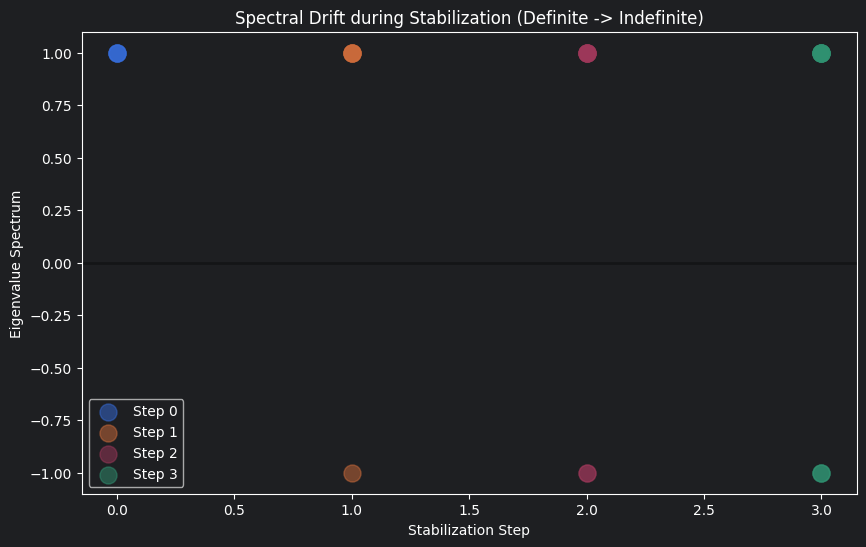

In [6]:
# Watch how eigenvalues shift around 0 as we stabilize
current_matrix = np.eye(4) # Rank 4 definite
evals_history = []

for _ in range(4):
    evals_history.append(np.linalg.eigvalsh(current_matrix))
    # Stabilize
    current_matrix = np.block([
        [current_matrix, np.zeros((current_matrix.shape[0], 2))],
        [np.zeros((2, current_matrix.shape[0])), np.array([[0, 1], [1, 0]])]
    ])

fig, ax = plt.subplots(figsize=(10, 6))
for i, evals in enumerate(evals_history):
    ax.scatter([i]*len(evals), evals, s=150, alpha=0.5, label=f'Step {i}')

ax.axhline(0, color='black', lw=2, alpha=0.3)
ax.set_xlabel('Stabilization Step')
ax.set_ylabel('Eigenvalue Spectrum')
ax.set_title('Spectral Drift during Stabilization (Definite -> Indefinite)')
ax.legend()
plt.show()

## Failure Modes

1. **Degenerate Bilinear Forms**: The Arf invariant is only well-defined for non-degenerate forms over $\mathbb{Z}_2$. Passing a singular matrix will raise a `DimensionError` or `UnimodularityError`.
2. **Dimension Constraints**: Arf invariants are typically used in $2 \pmod 4$ dimensions. Attempting to compute one for a manifold of incorrect parity will trigger a `DimensionError`.
3. **Refinement Mismatch**: The length of the `q_refinement` list must match the rank of the underlying intersection matrix.


In [7]:
try:
    # Error: Degenerate matrix over GF(2)
    A_deg = np.array([[1, 1], [1, 1]])
    QuadraticForm(matrix=A_deg, dimension=4, q_refinement=[1, 1]).arf_invariant()
except Exception as e:
    print(f'Caught expected error: {e}')

Caught expected error: Arf invariant is undefined for degenerate GF(2) bilinear forms.


## Summary Checklist
- [x] Defined Quadratic Forms as refinements of Intersection Forms.
- [x] Computed the Arf Invariant for twisted vs standard hyperbolic pairs.
- [x] Implemented algebraic stabilization via $\oplus H$.
- [x] Observed the transition from definite to indefinite signatures.
- [x] Visualized spectral drift during topological stabilization.

## Exercises
1. **Arf Symmetry**: Prove that if $q_1$ has Arf $a$ and $q_2$ has Arf $b$, then $q_1 \oplus q_2$ has Arf $a + b$.
2. **CP2 Stabilization**: How many stabilizations are required for a rank-10 definite form to become "very indefinite" ($|signature| \ll rank$)?
3. **E8 Stabilization**: Stabilize the $E8$ matrix once and compute its new Arf invariant (over $\mathbb{Z}_2$).
4. **Symplectic Basis**: Manually transform a non-standard hyperbolic matrix into the standard form $\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ over $\mathbb{Z}_2$.
5. **Geometry of Arf**: Explain why the Arf invariant 1 corresponds to a "knot" in the framing of a surgery sphere.

## Key Takeaways
- **Quadratic Forms** are essential for $L$-groups in dimensions $2, 6, 10, \dots$
- The **Arf Invariant** is the binary key that distinguishes stable isomorphism classes.
- **Stabilization** makes the classification of 4-manifolds tractable.
- Indefinite forms are the **stable limit** of topological classification.

**Ready for [09 - Fundamental Group and Group-Ring Basics](./09_fundamental_group_and_group_ring_basics.ipynb)**
